In [86]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.data_manager import generate_crisis_data
from src.causal_engine import UpliftCausalEngine
from src.mcda_engine import run_committee_mcda
from src.validator import validate_shock_input

Data Generator Validation

In [87]:
df = generate_crisis_data(1.2)

df.head()

,Global_Oil_Risk,DOE_Optimization,UPLIFT_Intensity,Stability_Index
0,68.940855,73.993554,0.409675,87.748221
1,57.511243,69.246337,0.411715,100.755859
2,71.658394,60.596304,0.410306,89.041792
3,87.414537,53.530632,0.559430,89.551756
4,55.785239,66.982233,0.183463,102.835813


In [88]:
df.describe()

,Global_Oil_Risk,DOE_Optimization,UPLIFT_Intensity,Stability_Index
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,60.347977,60.708362,0.446452,101.001821
std,17.625887,9.974544,0.159564,13.471344
min,1.657188,30.596114,0.000000,62.713842
25%,48.343375,53.937583,0.334809,92.176247
50%,60.455411,60.630771,0.439615,100.909658
75%,71.662990,67.288822,0.555094,110.054560
max,129.349167,91.931076,1.000000,143.088274


In [89]:
df.corr(numeric_only=True)

,Global_Oil_Risk,DOE_Optimization,UPLIFT_Intensity,Stability_Index
Global_Oil_Risk,1.000000,-0.040400,0.638141,-0.871807
DOE_Optimization,-0.040400,1.000000,-0.033717,0.233579
UPLIFT_Intensity,0.638141,-0.033717,1.000000,-0.376143
Stability_Index,-0.871807,0.233579,-0.376143,1.000000


In [90]:
engine = UpliftCausalEngine(df)

ate = engine.estimate_causal_lift()

print("ATE:", ate)

2026-05-14 00:10:04,168 - src.causal_engine - INFO - Identifying Causal Effect using Explicit EO 110 DAG.
ATE: 25.76834146289893


/Users/david/Documents/2026/Causal_PhUplift/.venv/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:128: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]


In [91]:
print(engine.learner.params)

print(engine.learner.model.exog_names)

const               121.815076
Global_Oil_Risk      -0.809678
DOE_Optimization      0.271627
UPLIFT_Intensity     25.891188
dtype: float64
['const', 'Global_Oil_Risk', 'DOE_Optimization', 'UPLIFT_Intensity']


In [92]:
levels = [0.0, 0.25, 0.5, 0.75, 0.95]

results = []

for lvl in levels:
    pred = engine.do_calculus_simulation(lvl)
    results.append((lvl, pred))

results

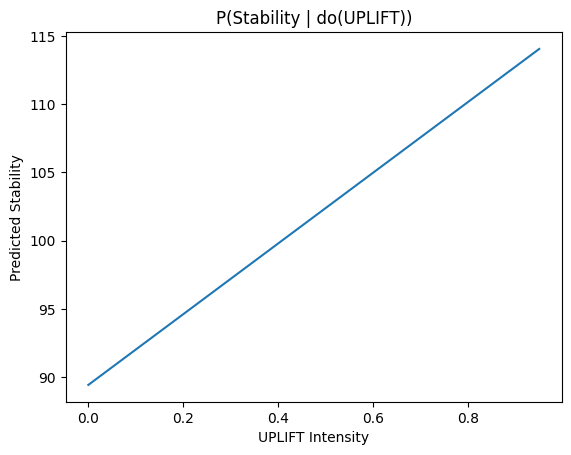

In [93]:
import matplotlib.pyplot as plt

x = [r[0] for r in results]
y = [r[1] for r in results]

plt.plot(x, y)
plt.title("P(Stability | do(UPLIFT))")
plt.xlabel("UPLIFT Intensity")
plt.ylabel("Predicted Stability")
plt.show()

In [94]:
scenarios = []

for lvl, pred in results:
    scenarios.append({
        "scenario": f"{lvl}",
        "intensity": lvl,
        "stability_pred": pred
    })

ranked, weights = run_committee_mcda(scenarios, 2.5)

ranked

,scenario,intensity,stability_pred,M_Stability,M_Welfare,M_Fiscal,n_M_Stability,n_M_Welfare,n_M_Fiscal,MCDA_Score
4,0.95,0.95,114.039287,114.039287,95.0,5.0,1.000000,1.000000,0.000000,0.900000
3,0.75,0.75,108.861050,108.861050,75.0,25.0,0.789474,0.789474,0.210526,0.731579
2,0.5,0.50,102.388253,102.388253,50.0,50.0,0.526316,0.526316,0.473684,0.521053
1,0.25,0.25,95.915456,95.915456,25.0,75.0,0.263158,0.263158,0.736842,0.310526
0,0.0,0.00,89.442659,89.442659,0.0,100.0,0.000000,0.000000,1.000000,0.100000


In [95]:
for shock in [1.0, 2.0, 3.0, 4.0]:
    df = generate_crisis_data(shock)

    engine = UpliftCausalEngine(df)

    ate = engine.estimate_causal_lift()

    print(f"Shock {shock} → ATE {ate:.2f}")

2026-05-14 00:10:04,297 - src.causal_engine - INFO - Identifying Causal Effect using Explicit EO 110 DAG.
Shock 1.0 → ATE 25.77
2026-05-14 00:10:04,307 - src.causal_engine - INFO - Identifying Causal Effect using Explicit EO 110 DAG.
Shock 2.0 → ATE 25.82
2026-05-14 00:10:04,314 - src.causal_engine - INFO - Identifying Causal Effect using Explicit EO 110 DAG.
Shock 3.0 → ATE 26.18
2026-05-14 00:10:04,322 - src.causal_engine - INFO - Identifying Causal Effect using Explicit EO 110 DAG.
Shock 4.0 → ATE 26.53


/Users/david/Documents/2026/Causal_PhUplift/.venv/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:128: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/Users/david/Documents/2026/Causal_PhUplift/.venv/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:128: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/Users/david/Documents/2026/Causal_PhUplift/.venv/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:128: FutureWarning: Series.__getitem__ treating keys as

In [96]:
print("=== VALIDATION SUMMARY ===")
print("ATE:", ate)
print("Monotonicity:", all(y[i] <= y[i+1] for i in range(len(y)-1)))
print("MCDA OK:", ranked is not None)

=== VALIDATION SUMMARY ===
ATE: 26.526768712566934
Monotonicity: True
MCDA OK: True
